# GFDL dynamics: forced-ocean parameterization comparison

GFDL's counterpart to CESM's `dynamics.ipynb`. Per scope agreed for this
notebook:

- **Not attempted** (out of scope): surface isopycnal (Redi) diffusivity,
  parameterized (GM) overturning at 1000 m, APE dissipation by the buoyancy
  parameterization, energy injection by the uANN momentum scheme.
- **Sections 1-2** (regridded 1x1deg grid): mean SSH bias vs GLORYS (from
  `zos`, `ocean_monthly_1x1deg`) and SSH variability vs altimeter (from
  `SSH`, `ocean_daily_1x1deg`) -- both computed by `gfdl_ssh.py`.
- **Sections 3-7** (native tripolar grid): barotropic streamfunction,
  current speed at the surface and at 2500 m, the equatorial undercurrent
  section at 165E, the ACC/Drake Passage zonal-velocity section at 70W, and
  the ACC (Drake Passage) transport time series -- all computed by
  `gfdl_native_velocity.py` from real `umo`/`uo`/`vo`/`thetao`/`so` in
  GFDL's `ocean_annual_z` stream (the same native-grid stream
  `gfdl_moc.ipynb`'s Section 7 uses).

Unlike CESM's tripolar grid, GFDL's own `ocean_monthly_1x1deg`/
`ocean_daily_1x1deg` grid (used in Sections 1-2) is **already regular 1x1
degree** -- and, checked directly, exactly coordinate-matched (not just
similar-resolution) to both observational grids used there
(`data/ssh_std_obs.nc`'s `lat`/`lon` and, after wrapping longitude to
0-360, `data/ssh_mean_glorys.nc`'s `xh`/`yh`), so no interpolation is
needed at all, unlike CESM's version which needs
`scipy.interpolate.RegularGridInterpolator`.

Sections 3-7 use a *second*, separate set of `Experiment` objects on GFDL's
native grid (the same `gfdl_<expt>_moc` yaml/folder pair `gfdl_moc.ipynb`
uses), since the barotropic streamfunction/current speed/EUC/Drake Passage
diagnostics all need real C-grid transport/velocity, which only exists on
that native grid -- `ocean_monthly_1x1deg` (Sections 1-2's regridded stream)
has no `umo`/`uo`/`vo` at all.

**Matching `dynamics.ipynb`'s conventions throughout:** every map figure is
a 2x2 grid (CTRL top-left, bANN top-right, uANN bottom-left, bANN_uANN
bottom-right, `PANEL_POS`) and uses `contourf` rather than `pcolormesh`.
Sections 3-4 (barotropic streamfunction, current speed) are restricted to
the North Atlantic and shown as **CTRL absolute + response** (`exp -
CTRL`), on two separate color scales -- the same convention
`dynamics.ipynb` uses for its own barotropic-streamfunction and
current-speed figures, and for the same reason: the parameterizations'
effect there is second-order against a much larger background circulation.
Sections 5-6 (EUC, ACC velocity sections) instead follow `dynamics.ipynb`'s
own Sections 9-10 exactly: a latitude-depth section at one fixed longitude,
observational references (Johnson climatology and/or GLORYS12) shown
alongside the 4 GFDL panels, and `gsw.sigma2` potential-density isolines
overlaid on every panel. The only structural difference from
`dynamics.ipynb` is the panel count/layout: CESM's version has 2 rows (one
per coupled/forced regime) x 4 columns (obs + 3 experiments); GFDL has only
one regime and 4 experiments, so these two sections use a single row of
(1 or 2 obs panels) + 4 experiment panels instead.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import gsw
import intake
import nc_time_axis  # lets matplotlib plot GFDL's cftime (julian calendar) axis directly

from experiment import Experiment

%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_1988_2012')

print('REPO     =', REPO)
print('GFDL_DIR =', GFDL_DIR)

REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_1988_2012


In [2]:
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())
CTRL = 'gfdl_CTRL'

LABELS = {
    'gfdl_CTRL':      'CTRL',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}

# 2x2 panel positions, matching LABELS/names (and, later, NLABELS/nnames)
# order: CTRL top-left, bANN top-right, uANN bottom-left, bANN_uANN
# bottom-right. Shared by every 2x2 figure in this notebook.
PANEL_POS = {0: (0, 0), 1: (0, 1), 2: (1, 0), 3: (1, 1)}

print('Initialized:', names)

[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 



[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


# 1. Mean SSH bias against GLORYS

Validation of mean SSH against the GLORYS reanalysis
(`data/ssh_mean_glorys.nc`, regular 1 degree lon/lat `zos`), computed by
`gfdl_ssh.py` from GFDL's own `zos` (`ocean_monthly_1x1deg`). SSH has an
arbitrary datum, so a common area-weighted global mean is removed from both
fields before differencing. Panel 1 (CTRL): bias (`CTRL - GLORYS`); panels
2-4: response (`exp - CTRL`), 2x2 grid. Every panel is annotated with the
area-weighted global RMSE of that experiment's SSH bias vs GLORYS.

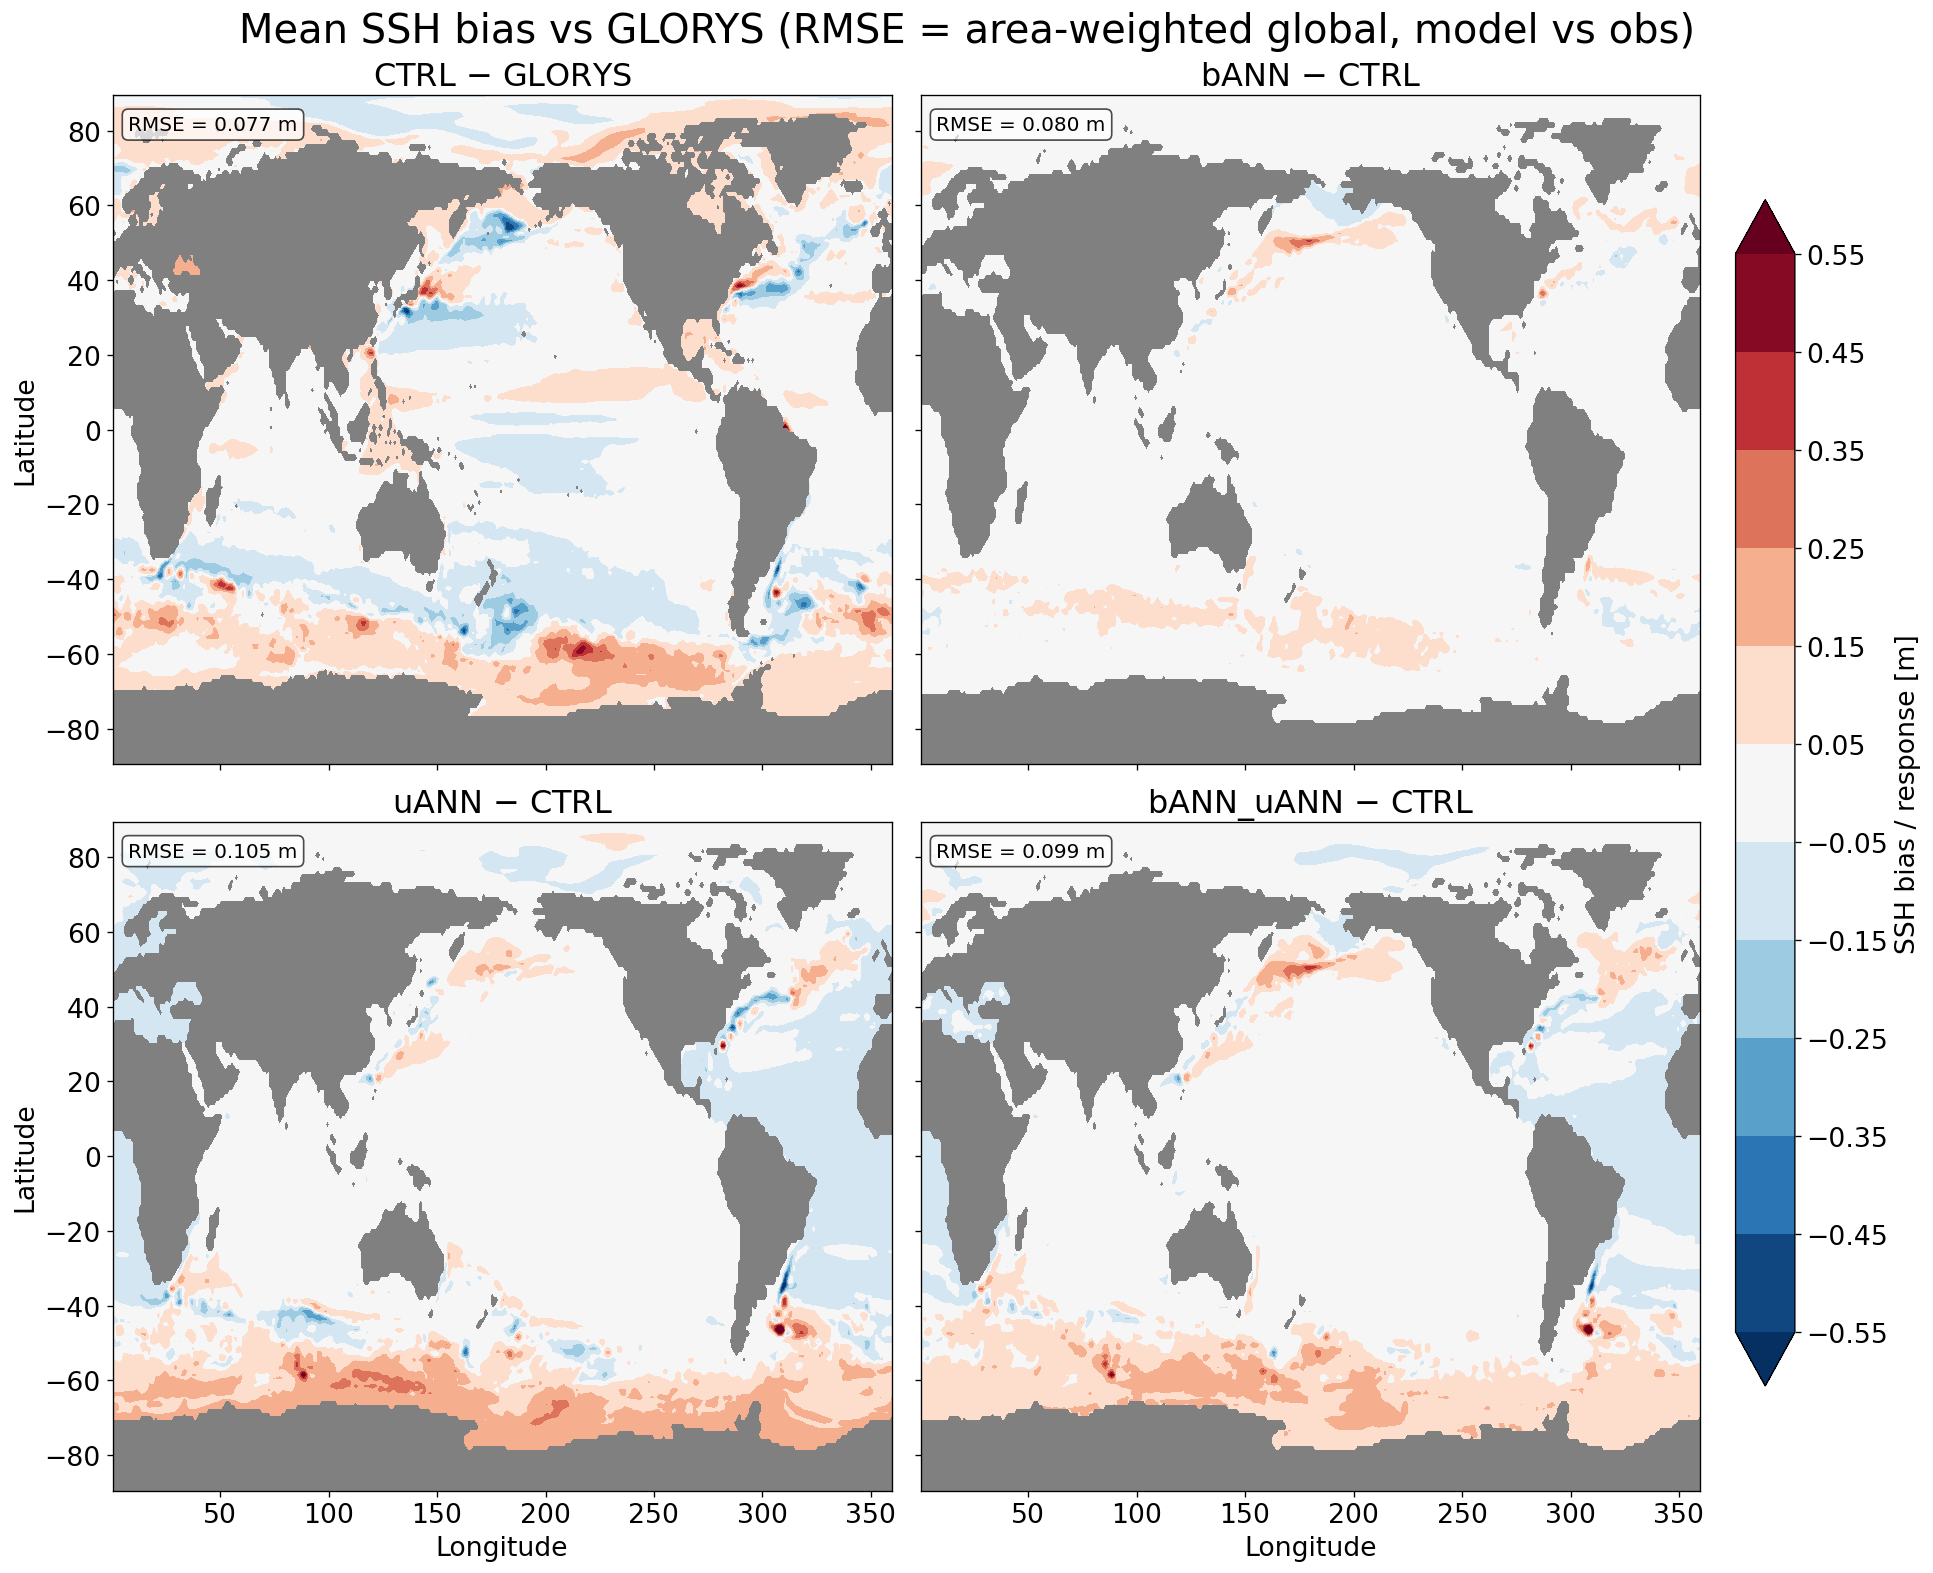

In [3]:
def _glorys_mean_on_gfdl():
    """GLORYS mean SSH, coordinate-matched onto GFDL's own 1x1deg grid --
    checked directly to be the identical grid up to a longitude convention
    (-180..180 vs 0..360), so a simple wrap + sort suffices, no
    interpolation. Returned as a plain numpy array (not xarray) -- see note
    below on why every field here is worked with as .values."""
    g = xr.open_dataset(os.path.join(REPO, 'data', 'ssh_mean_glorys.nc'))
    g = g.assign_coords(xh=(g.xh % 360.0)).sortby('xh')
    return g['zos'].values


# Every field below is immediately reduced to a plain numpy array (.values),
# not kept as an xarray DataArray: each Experiment loads its own grid
# independently, and even though all 4 share the identical GFDL grid, xarray
# binary ops (e.g. `mask_a & mask_b`) silently intersect by *coordinate
# value* when combining DataArrays from different Experiment objects -- any
# sub-float-precision difference between two independently-loaded copies of
# "the same" xh/yh coordinate shrinks the result to a mismatched subset
# instead of raising an error. Plain numpy avoids that entirely, since we've
# already confirmed (see cell above) this is genuinely one shared grid.
OBS_MEAN_SSH = _glorys_mean_on_gfdl()
AREA = {name: exps[name].area.fillna(0.0).values for name in names}
WET = {name: exps[name].grd.wet.values > 0 for name in names}


def _ssh_masked(name):
    field = exps[name].ssh()['mean_ssh'].values
    return np.where(WET[name], field, np.nan)


def _remove_mean(name, field, valid):
    """Remove the area-weighted mean over `valid` (SSH has an arbitrary datum)."""
    area = AREA[name]
    return field - np.nansum(np.where(valid, field, 0.0) * area) / area[valid].sum()


def _ssh_bias(name):
    """Model - GLORYS mean SSH, with a common global offset removed."""
    field = _ssh_masked(name)
    valid = np.isfinite(field) & np.isfinite(OBS_MEAN_SSH)
    return _remove_mean(name, field, valid) - _remove_mean(name, OBS_MEAN_SSH, valid), valid


def _rmse(name, bias, valid):
    area = AREA[name]
    return float(np.sqrt(np.nansum(np.where(valid, bias ** 2, 0.0) * area) / area[valid].sum()))


SSH_LEVELS = np.arange(-0.55, 0.6, 0.1)   # m

# 2x2 grid (CTRL top-left, bANN top-right, uANN bottom-left, bANN_uANN
# bottom-right), matching every native-grid figure in this notebook. Panel 0
# (CTRL) is the bias vs GLORYS; the other three are the response (exp -
# CTRL) -- both are SSH-anomaly-type quantities, so (like dynamics.ipynb's
# own SSH figure) they share one colorbar/levels, unlike the
# absolute-vs-response figures later in this notebook.
fig, axes = plt.subplots(2, 2, figsize=(16, 13), dpi=120,
                         sharex=True, sharey=True, constrained_layout=True)
cf = None
ctrl_bias, ctrl_valid = _ssh_bias(CTRL)
ctrl_ssh0 = _remove_mean(CTRL, _ssh_masked(CTRL), ctrl_valid)
for i, name in enumerate(names):
    row, col = PANEL_POS[i]
    ax = axes[row, col]
    ax.set_facecolor('gray')
    bias, valid = _ssh_bias(name)
    rmse = _rmse(name, bias, valid)
    exp = exps[name]
    if name == CTRL:
        field = bias
        title = f'{LABELS[name]} ' + r'$-$' + ' GLORYS'
    else:
        resp_valid = np.isfinite(_ssh_masked(name)) & ctrl_valid
        field = _remove_mean(name, _ssh_masked(name), resp_valid) - ctrl_ssh0
        title = f'{LABELS[name]} ' + r'$-$' + ' CTRL'
    cf = ax.contourf(exp.grd.xh.values, exp.grd.yh.values,
                     np.ma.masked_invalid(field), levels=SSH_LEVELS,
                     cmap='RdBu_r', extend='both')
    ax.text(0.02, 0.97, f'RMSE = {rmse:.3f} m', transform=ax.transAxes,
           va='top', ha='left', fontsize=12,
           bbox=dict(boxstyle='round', fc='white', alpha=0.7))
    ax.set_title(title)
    if row == 1:
        ax.set_xlabel('Longitude')
    if col == 0:
        ax.set_ylabel('Latitude')
cbar = fig.colorbar(cf, ax=axes, label='SSH bias / response [m]', extend='both',
                    ticks=SSH_LEVELS, shrink=0.85, pad=0.02)
fig.suptitle('Mean SSH bias vs GLORYS (RMSE = area-weighted global, model vs obs)', fontsize=24)
plt.show()

# 2. SSH variability (std) bias against altimeter

Validation of SSH *variability* against an altimeter product
(`data/ssh_std_obs.nc`, regular 1 degree lon/lat `adt` = SSH standard
deviation). The model std is `sqrt(ssh_variance)` from the same
`gfdl_ssh.py`-computed `*_SSH.nc` files. Std is an absolute quantity, so
(unlike mean SSH) no datum offset is removed.

`ssh_variance` is computed from **daily** SSH (`SSH` in
`ocean_daily_1x1deg`, a genuine separate variable from monthly `zos`, not a
resampled version of it), following `mom6_tools.surface.get_SSH`'s method:
resample daily SSH to 5-day means, then take the variance of those 5-day
means about their own time-mean over 1988-2012. This is the same recipe
CESM's `dynamics.ipynb` uses for its own SSH std figure (see that
notebook's Section 8), so the two should now be broadly comparable in what
kind of variability they capture (still short of what a true daily/eddy
timescale would give, since the underlying data was already averaged into
5-day means before differencing).

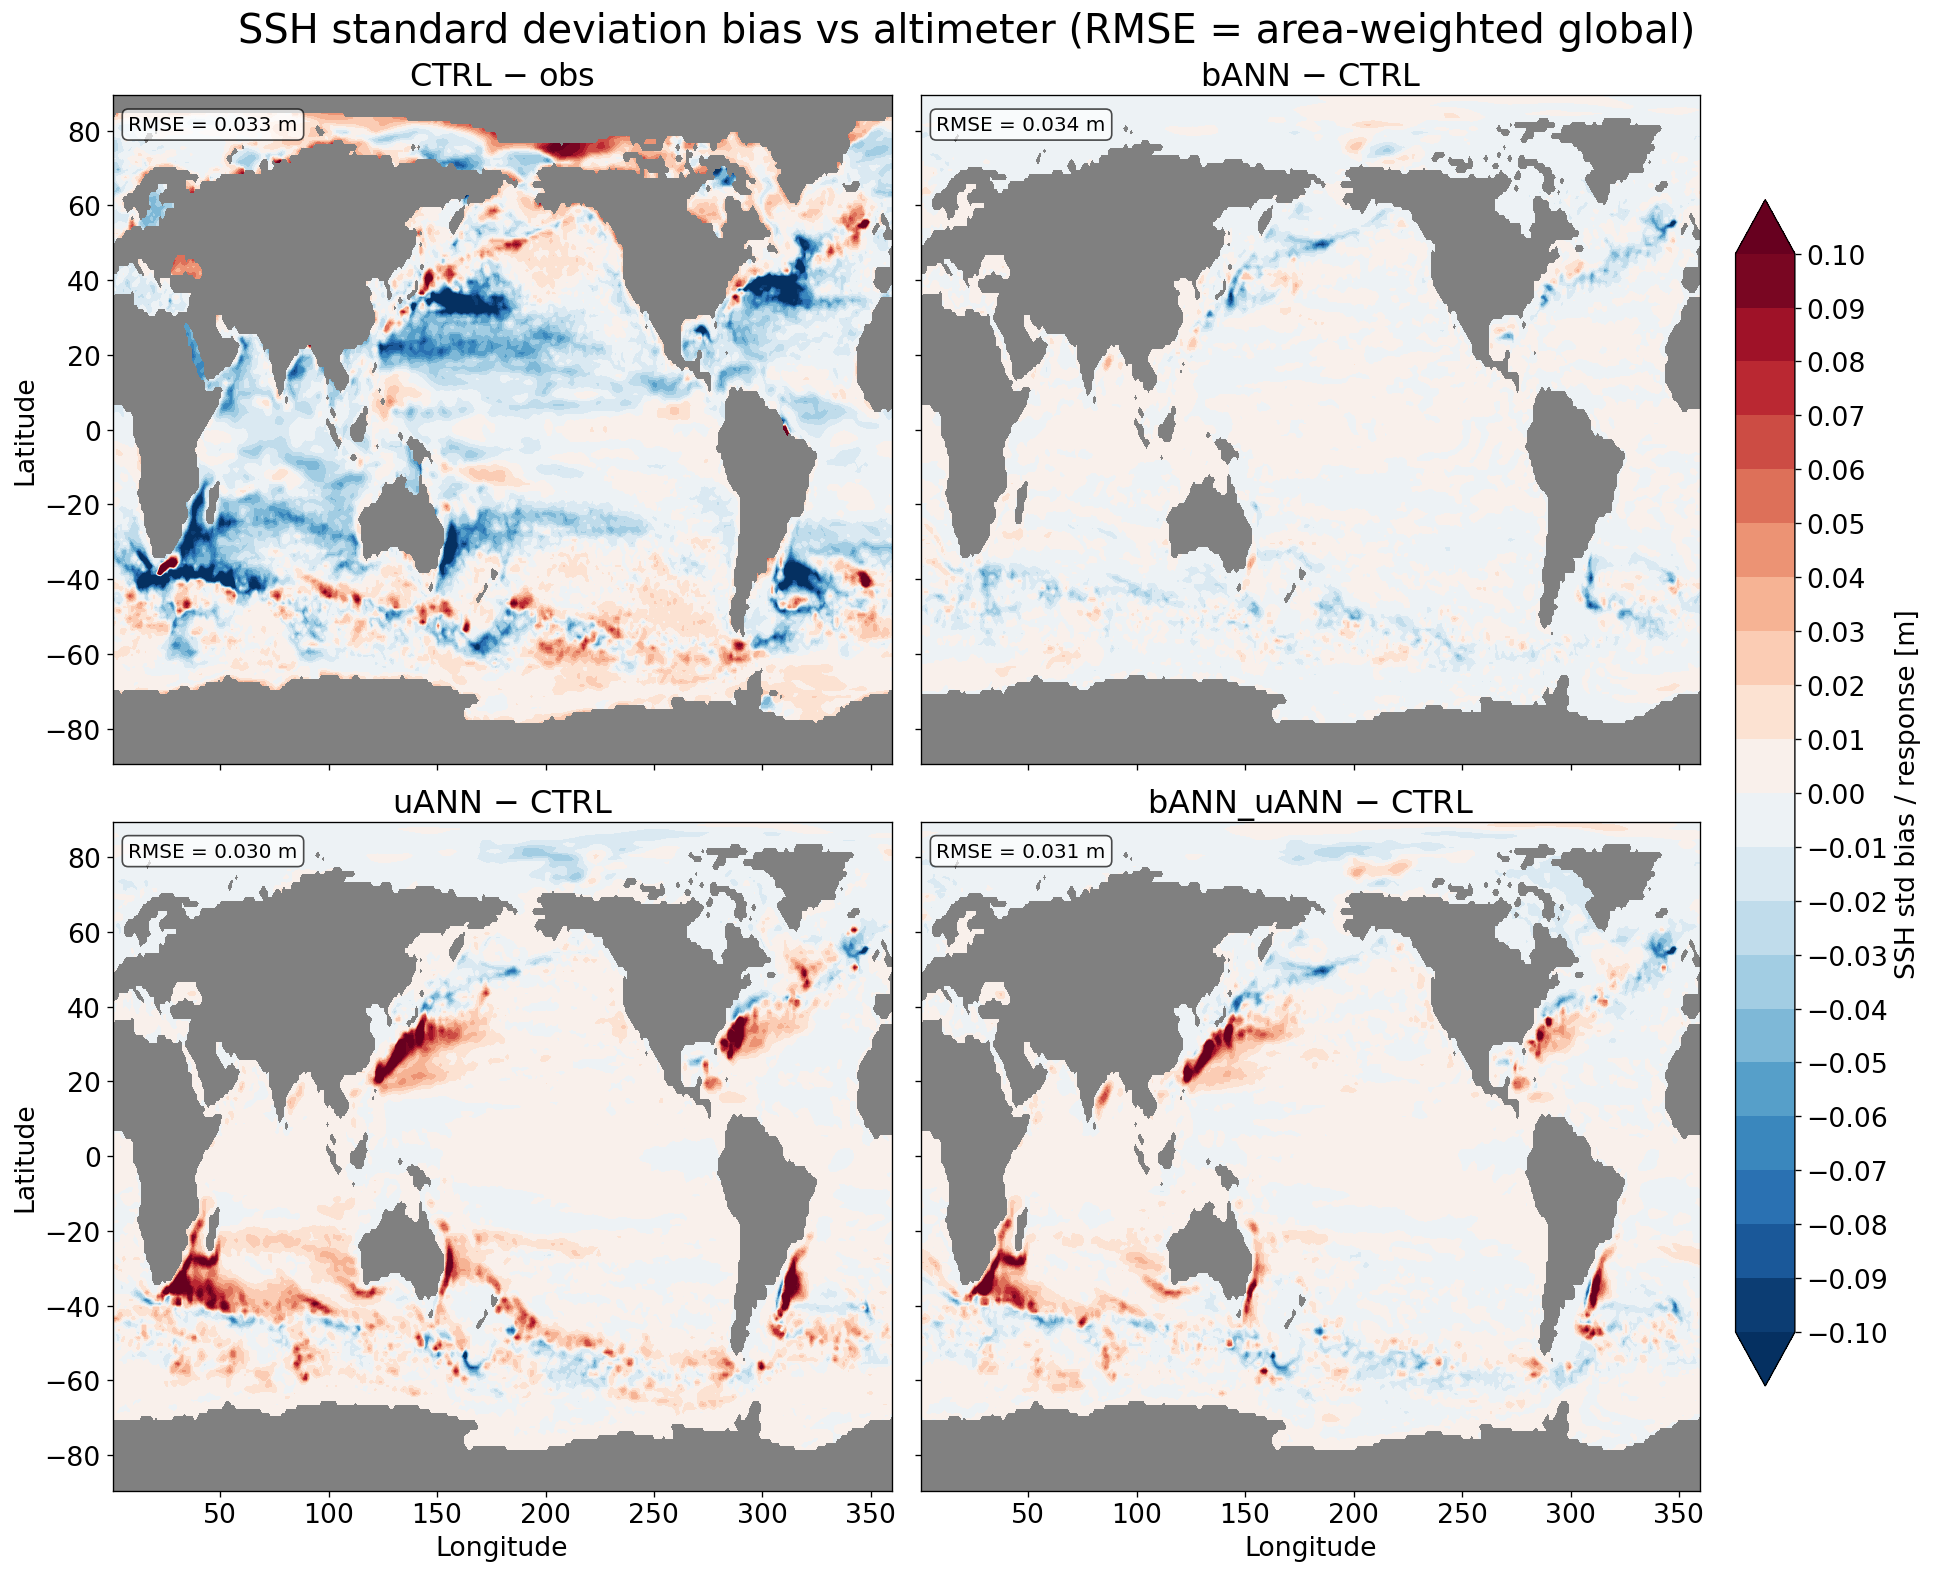

In [4]:
def _altimeter_std_on_gfdl():
    """Altimeter SSH std, already on the identical GFDL 1x1deg grid
    (checked directly) -- no interpolation needed."""
    o = xr.open_dataset(os.path.join(REPO, 'data', 'ssh_std_obs.nc'))
    return o['adt'].values


OBS_STD = _altimeter_std_on_gfdl()


def _ssh_std(name):
    field = np.sqrt(exps[name].ssh()['ssh_variance'].values)
    return np.where(WET[name], field, np.nan)


STD_LEVELS = np.arange(-0.1, 0.11, 0.01)   # m

# 2x2 grid, same convention as Section 1: panel 0 (CTRL) = bias vs obs, the
# other three = response (exp - CTRL), one shared colorbar.
fig, axes = plt.subplots(2, 2, figsize=(16, 13), dpi=120,
                         sharex=True, sharey=True, constrained_layout=True)
cf = None
ctrl_std = _ssh_std(CTRL)
for i, name in enumerate(names):
    row, col = PANEL_POS[i]
    ax = axes[row, col]
    ax.set_facecolor('gray')
    exp = exps[name]
    std = _ssh_std(name)
    bias = std - OBS_STD
    valid = np.isfinite(std) & np.isfinite(OBS_STD)
    rmse = float(np.sqrt(np.nansum(np.where(valid, bias ** 2, 0.0) * AREA[name]) / AREA[name][valid].sum()))
    if name == CTRL:
        field = bias
        title = f'{LABELS[name]} ' + r'$-$' + ' obs'
    else:
        field = std - ctrl_std
        title = f'{LABELS[name]} ' + r'$-$' + ' CTRL'
    cf = ax.contourf(exp.grd.xh.values, exp.grd.yh.values,
                     np.ma.masked_invalid(field), levels=STD_LEVELS,
                     cmap='RdBu_r', extend='both')
    ax.text(0.02, 0.97, f'RMSE = {rmse:.3f} m', transform=ax.transAxes,
           va='top', ha='left', fontsize=12,
           bbox=dict(boxstyle='round', fc='white', alpha=0.7))
    ax.set_title(title)
    if row == 1:
        ax.set_xlabel('Longitude')
    if col == 0:
        ax.set_ylabel('Latitude')
cbar = fig.colorbar(cf, ax=axes, label='SSH std bias / response [m]', extend='both',
                    ticks=STD_LEVELS, shrink=0.85, pad=0.02)
fig.suptitle('SSH standard deviation bias vs altimeter (RMSE = area-weighted global)', fontsize=24)
plt.show()

## Native-grid experiments (Sections 3-6)

Separate `Experiment` set on GFDL's native tripolar grid (same
`gfdl_<expt>_moc` yaml/folder as `gfdl_moc.ipynb`), needed for
`grd.geolon_c`/`geolat_c`/`wet` etc. The underlying data
(`gfdl_native_velocity.py`'s output) is read directly via plain
`xr.open_dataset` rather than through an `Experiment` reader method, since
there's no existing one for these new file types.

In [5]:
MOC_DIR = os.path.join(REPO, 'data', 'gfdl_moc_1988_2012')

native_experiment_defs = [
    ('gfdl_CTRL_moc',       'CTRL'),
    ('gfdl_bANN_moc',       'bANN'),
    ('gfdl_uANN_moc',       'uANN'),
    ('gfdl_bANN_uANN_moc',  'bANN_uANN'),
]
EXPT_OF = dict(native_experiment_defs)   # 'gfdl_CTRL_moc' -> 'CTRL', for gfdl_native_velocity.py's file names

nexps = {}
for name, expt in native_experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'gfdl_{expt}_moc.yaml')
    nexps[name] = Experiment(yaml_path, folder=MOC_DIR, name=name,
                             load_grid=True, verbose=True)

nnames = list(nexps.keys())
NCTRL = 'gfdl_CTRL_moc'

NLABELS = {
    'gfdl_CTRL_moc':      'CTRL',
    'gfdl_bANN_moc':      'bANN',
    'gfdl_uANN_moc':      'uANN',
    'gfdl_bANN_uANN_moc': 'bANN_uANN',
}
NCOLORS = {
    'gfdl_CTRL_moc':      'k',
    'gfdl_bANN_moc':      '#0072B2',
    'gfdl_uANN_moc':      '#E69F00',
    'gfdl_bANN_uANN_moc': '#009E73',
}
# PANEL_POS (CTRL top-left, bANN top-right, uANN bottom-left, bANN_uANN
# bottom-right) was already defined above for names/LABELS -- nnames follows
# the identical order, so it's reused as-is here.


def native_file(name, suffix):
    """gfdl_native_velocity.py writes ncfiles/gfdl_<expt>_<suffix> (its own
    'case' = f'gfdl_{expt}', not the '_moc' name used for the Experiment
    objects/yamls here)."""
    return os.path.join(MOC_DIR, f'gfdl_{EXPT_OF[name]}_{suffix}')


print('Initialized (native grid):', nnames)

[gfdl_CTRL_moc] casename=gfdl_CTRL_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format_moc/run
MOM6 grid successfully loaded... 



[gfdl_bANN_moc] casename=gfdl_bANN_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format_moc/run
MOM6 grid successfully loaded... 



[gfdl_uANN_moc] casename=gfdl_uANN_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format_moc/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN_moc] casename=gfdl_bANN_uANN_moc, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format_moc/run
MOM6 grid successfully loaded... 



Initialized (native grid): ['gfdl_CTRL_moc', 'gfdl_bANN_moc', 'gfdl_uANN_moc', 'gfdl_bANN_uANN_moc']


# 3. Barotropic (depth-integrated) streamfunction

Barotropic streamfunction, following the CDFtools algorithm
(`Experiment.compute_barotropic_streamfunction`'s own approach, ported to
GFDL's native grid by `gfdl_native_velocity.py`): depth-integrated zonal
transport `umo` (kg/s), cumulatively integrated meridionally from the
southern boundary, converted to Sv, and offset to zero over the Americas
(same reference point CESM's version uses). Time-mean over 1988-2012.

Shown restricted to the **North Atlantic** (20-70N, 90W-0), matching
`dynamics.ipynb`'s own barotropic-streamfunction figure, since that is
where the subtropical/subpolar gyre structure -- the part of this
diagnostic sensitive to the buoyancy/momentum parameterizations -- actually
lives; the Southern Ocean/ACC signal that dominates the global field (see
the previous version of this section) would otherwise swamp it. Four
panels, 2x2: panel 1 (CTRL) is the absolute streamfunction; the other three
are the **response** (`exp - CTRL`), on a separate, much narrower color
scale, since the parameterization changes are a second-order effect on top
of the gyre circulation.

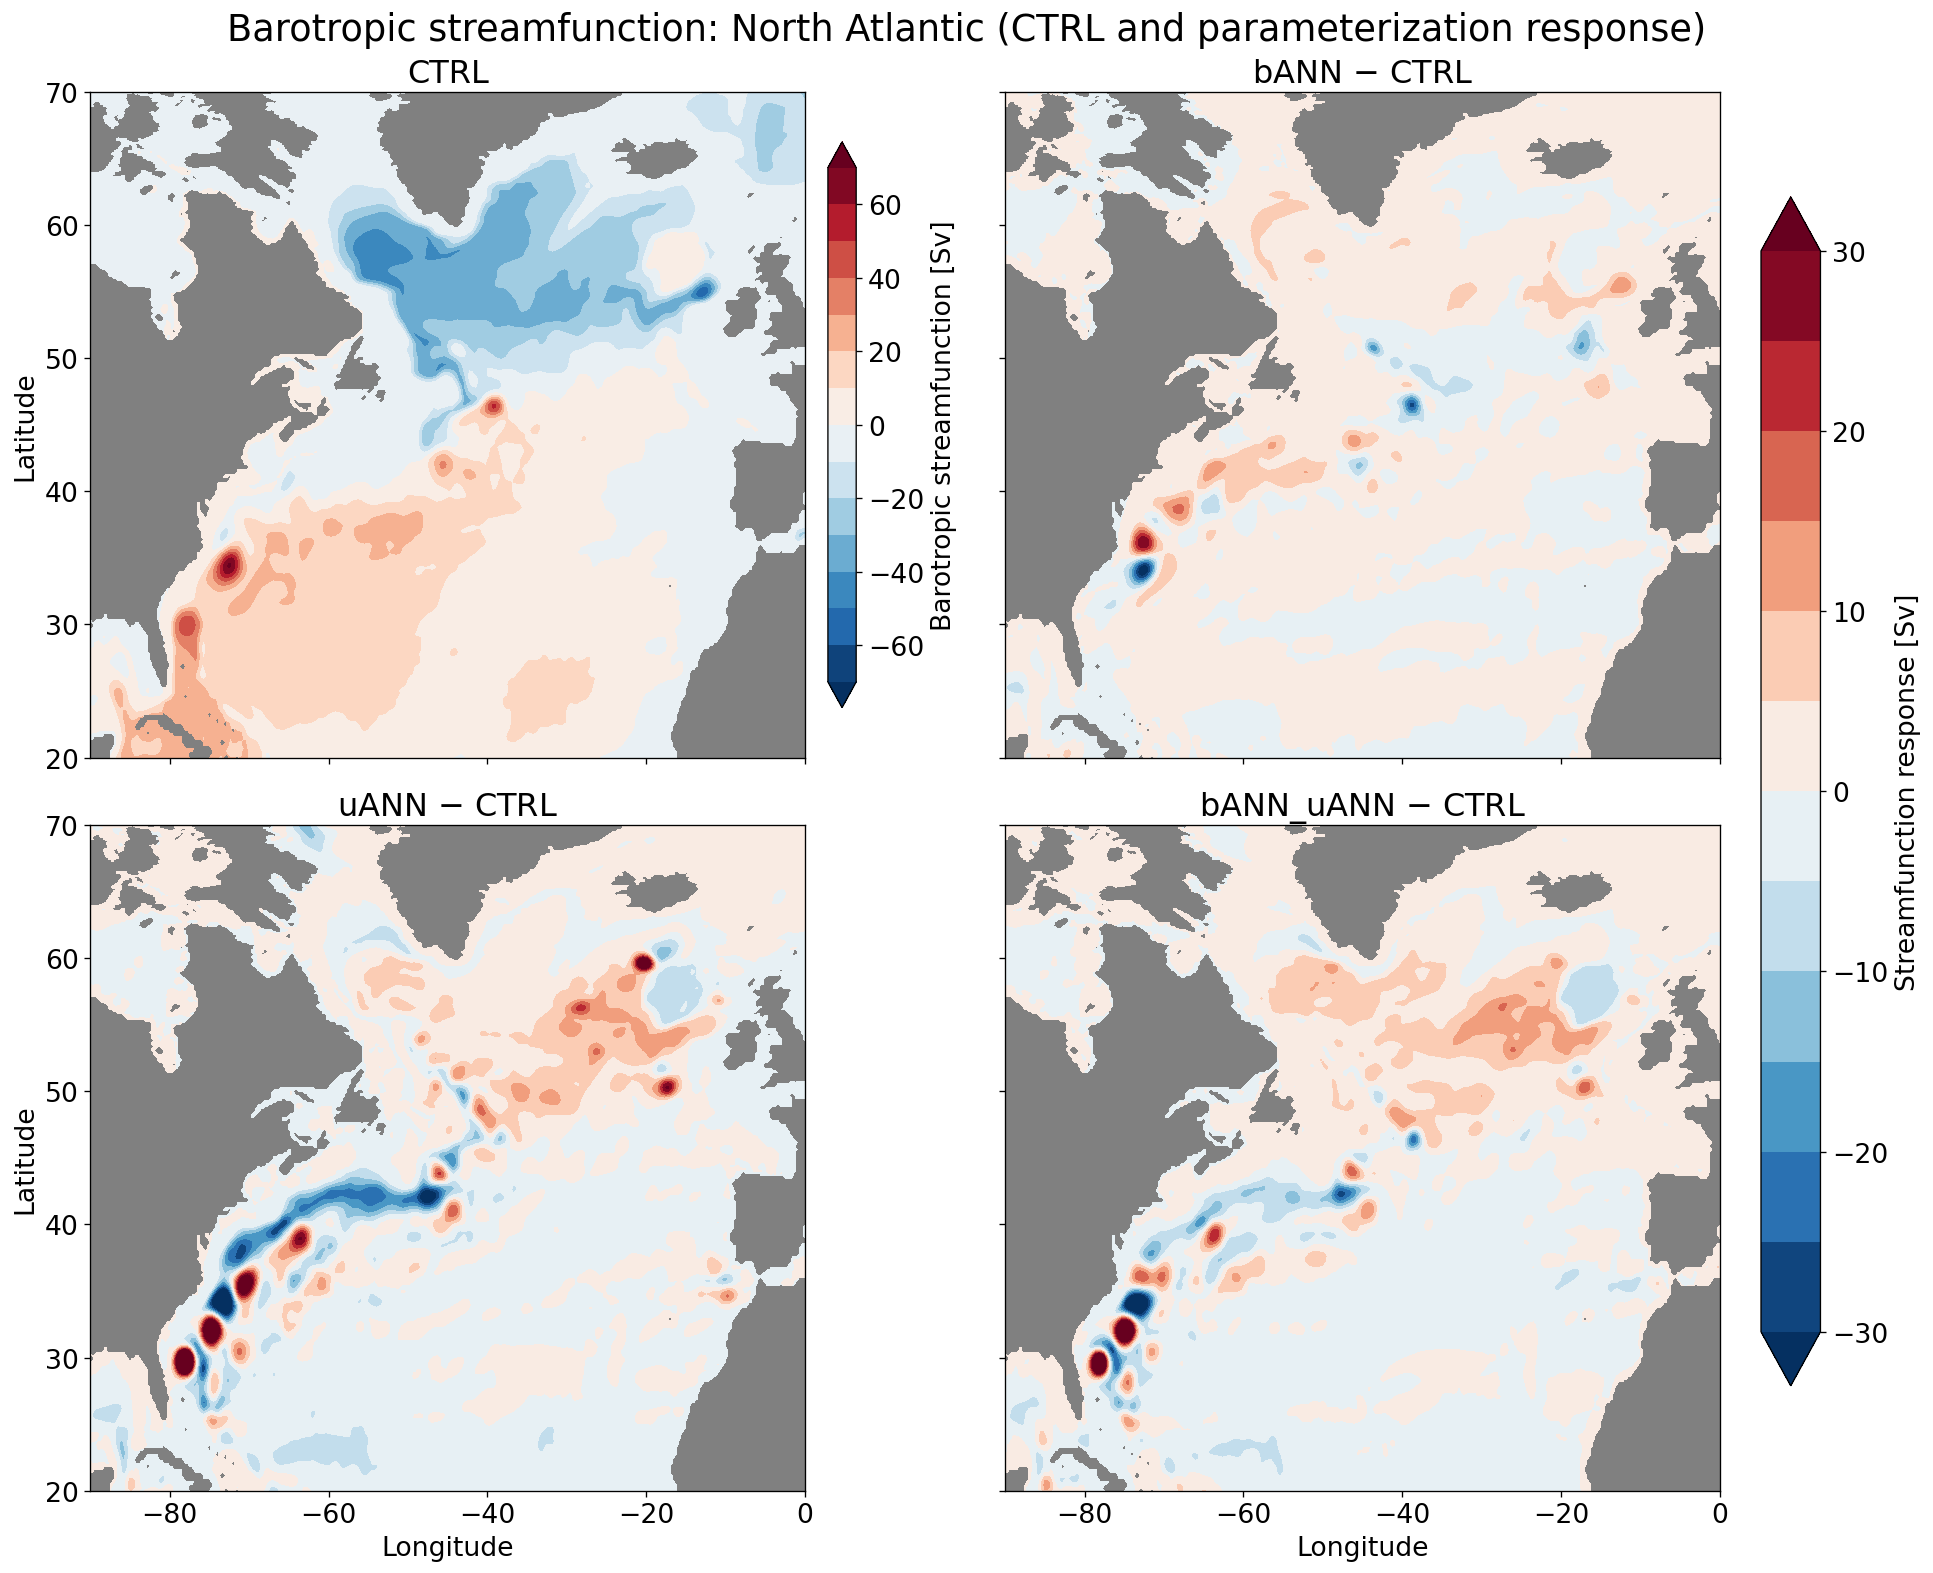

In [6]:
def plot_native_response_2x2(get_field_xy, abs_levels, abs_cmap, abs_label,
                             resp_levels, resp_cmap, resp_label,
                             suptitle, xlim=None, ylim=None):
    """2x2 grid (CTRL/bANN top, uANN/bANN_uANN bottom): the CTRL panel shows
    the absolute field; the other three show the response (experiment -
    CTRL), on a separate color scale/colorbar -- same convention as
    dynamics.ipynb's barotropic-streamfunction and current-speed figures.
    ``get_field_xy(name)`` returns (X, Y, Z) 2D numpy arrays for contourf."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 13), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    _, _, field_ctrl = get_field_xy(NCTRL)
    cf_abs = None
    cf_resp = None
    for i, name in enumerate(nnames):
        row, col = PANEL_POS[i]
        ax = axes[row, col]
        ax.set_facecolor('gray')
        x, y, field = get_field_xy(name)
        if name == NCTRL:
            cf_abs = ax.contourf(x, y, field, levels=abs_levels, cmap=abs_cmap, extend='both')
            title = NLABELS[name]
        else:
            cf_resp = ax.contourf(x, y, field - field_ctrl, levels=resp_levels,
                                  cmap=resp_cmap, extend='both')
            title = f'{NLABELS[name]} ' + r'$-$' + ' CTRL'
        ax.set_title(title)
        if row == 1:
            ax.set_xlabel('Longitude')
        if col == 0:
            ax.set_ylabel('Latitude')
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
    if cf_abs is not None:
        fig.colorbar(cf_abs, ax=axes[PANEL_POS[0]], label=abs_label, extend='both', shrink=0.85, pad=0.02)
    if cf_resp is not None:
        resp_axes = [axes[PANEL_POS[i]] for i in range(1, 4)]
        fig.colorbar(cf_resp, ax=resp_axes, label=resp_label, extend='both', shrink=0.85, pad=0.02)
    fig.suptitle(suptitle, fontsize=22)
    plt.show()


NA_XLIM = (-90, 0)      # North Atlantic longitude window (dynamics.ipynb convention)
NA_YLIM_BSF = (20, 70)  # dynamics.ipynb's own barotropic-streamfunction North Atlantic window

BSF_LEVELS = np.arange(-70, 80, 10)       # Sv, CTRL absolute (checked directly: North Atlantic CTRL
                                          # spans about -58 to 71 Sv -- wider than dynamics.ipynb's own
                                          # +-32.5 Sv cap, which would badly saturate GFDL's gyre)
BSF_RESP_LEVELS = np.arange(-30, 35, 5)  # Sv, response (checked directly: typical |response| ~5-13 Sv,
                                          # with rare much larger single-pixel outliers near the coast)


def _bsf_xy(name):
    ds = xr.open_dataset(native_file(name, 'barotropic_streamfunction.nc'))
    return ds['geolonb'].values, ds['geolatb'].values, ds['psi_barotropic'].values


plot_native_response_2x2(_bsf_xy, BSF_LEVELS, 'RdBu_r', 'Barotropic streamfunction [Sv]',
                         BSF_RESP_LEVELS, 'RdBu_r', 'Streamfunction response [Sv]',
                         'Barotropic streamfunction: North Atlantic (CTRL and parameterization response)',
                         xlim=NA_XLIM, ylim=NA_YLIM_BSF)

# 4. Current speed (North Atlantic): surface and 2500 m

Modulus of the velocity, $\sqrt{u^2+v^2}$, from `uo`/`vo` on GFDL's native
C-grid; `gfdl_native_velocity.py` linearly interpolates each onto the
tracer grid along its own staggered dimension (`xq` -> `xh`, `yq` -> `yh`)
before combining. Two depths, matching `dynamics.ipynb`'s own two
current-speed diagnostics exactly:

- **Surface**: shallowest `uo`/`vo` level (2.5 m).
- **2500 m**: nearest `uo`/`vo` z-level to 2500 m depth.

Both restricted to the **North Atlantic** (20-65N, 90W-0), matching
`dynamics.ipynb`'s own current-speed figures, where the Gulf Stream / DWBC
and the parameterizations' effect on them are best resolved. Same
convention as Section 3: panel 1 (CTRL) is the absolute speed; the other
three are the **response** (`exp - CTRL`), on a separate color scale.

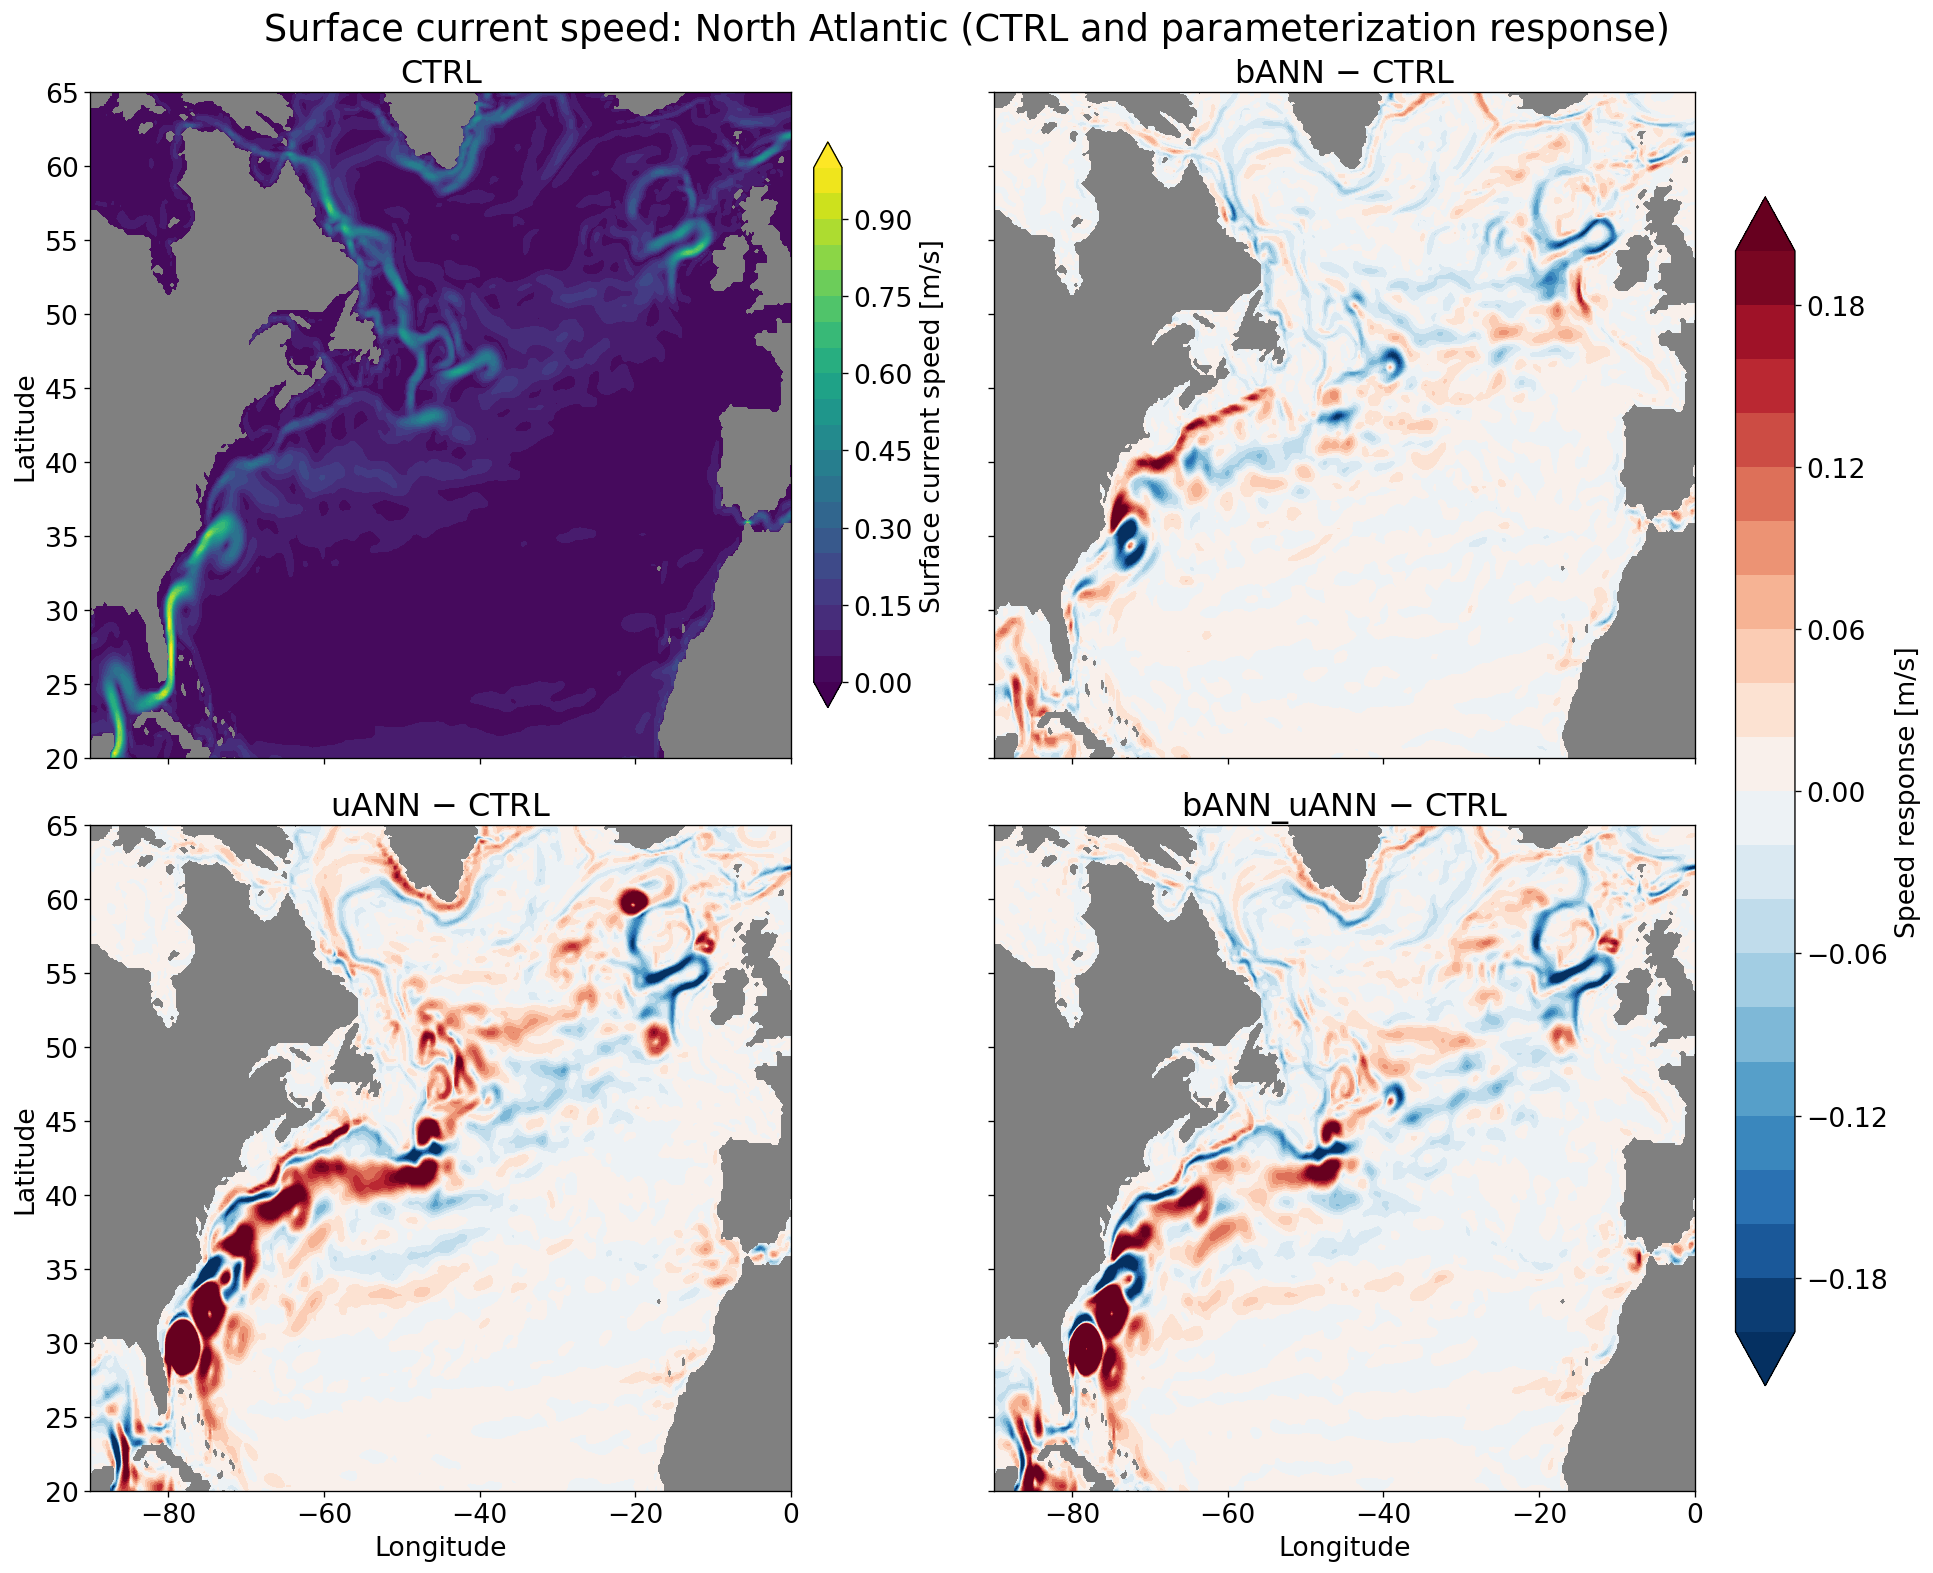

In [7]:
NA_YLIM_SPEED = (20, 65)   # dynamics.ipynb's own current-speed North Atlantic window (excludes Arctic cap)

SPEED_LEVELS = np.arange(0, 1.05, 0.05)          # m/s, CTRL absolute
SPEED_RESP_LEVELS = np.arange(-0.2, 0.22, 0.02)  # m/s, response


def _speed_surf_xy(name):
    ds = xr.open_dataset(native_file(name, 'current_speed.nc'))
    grd = nexps[name].grd
    return grd.geolon.values, grd.geolat.values, ds['speed_surf'].values


plot_native_response_2x2(_speed_surf_xy, SPEED_LEVELS, 'viridis', 'Surface current speed [m/s]',
                         SPEED_RESP_LEVELS, 'RdBu_r', 'Speed response [m/s]',
                         'Surface current speed: North Atlantic (CTRL and parameterization response)',
                         xlim=NA_XLIM, ylim=NA_YLIM_SPEED)

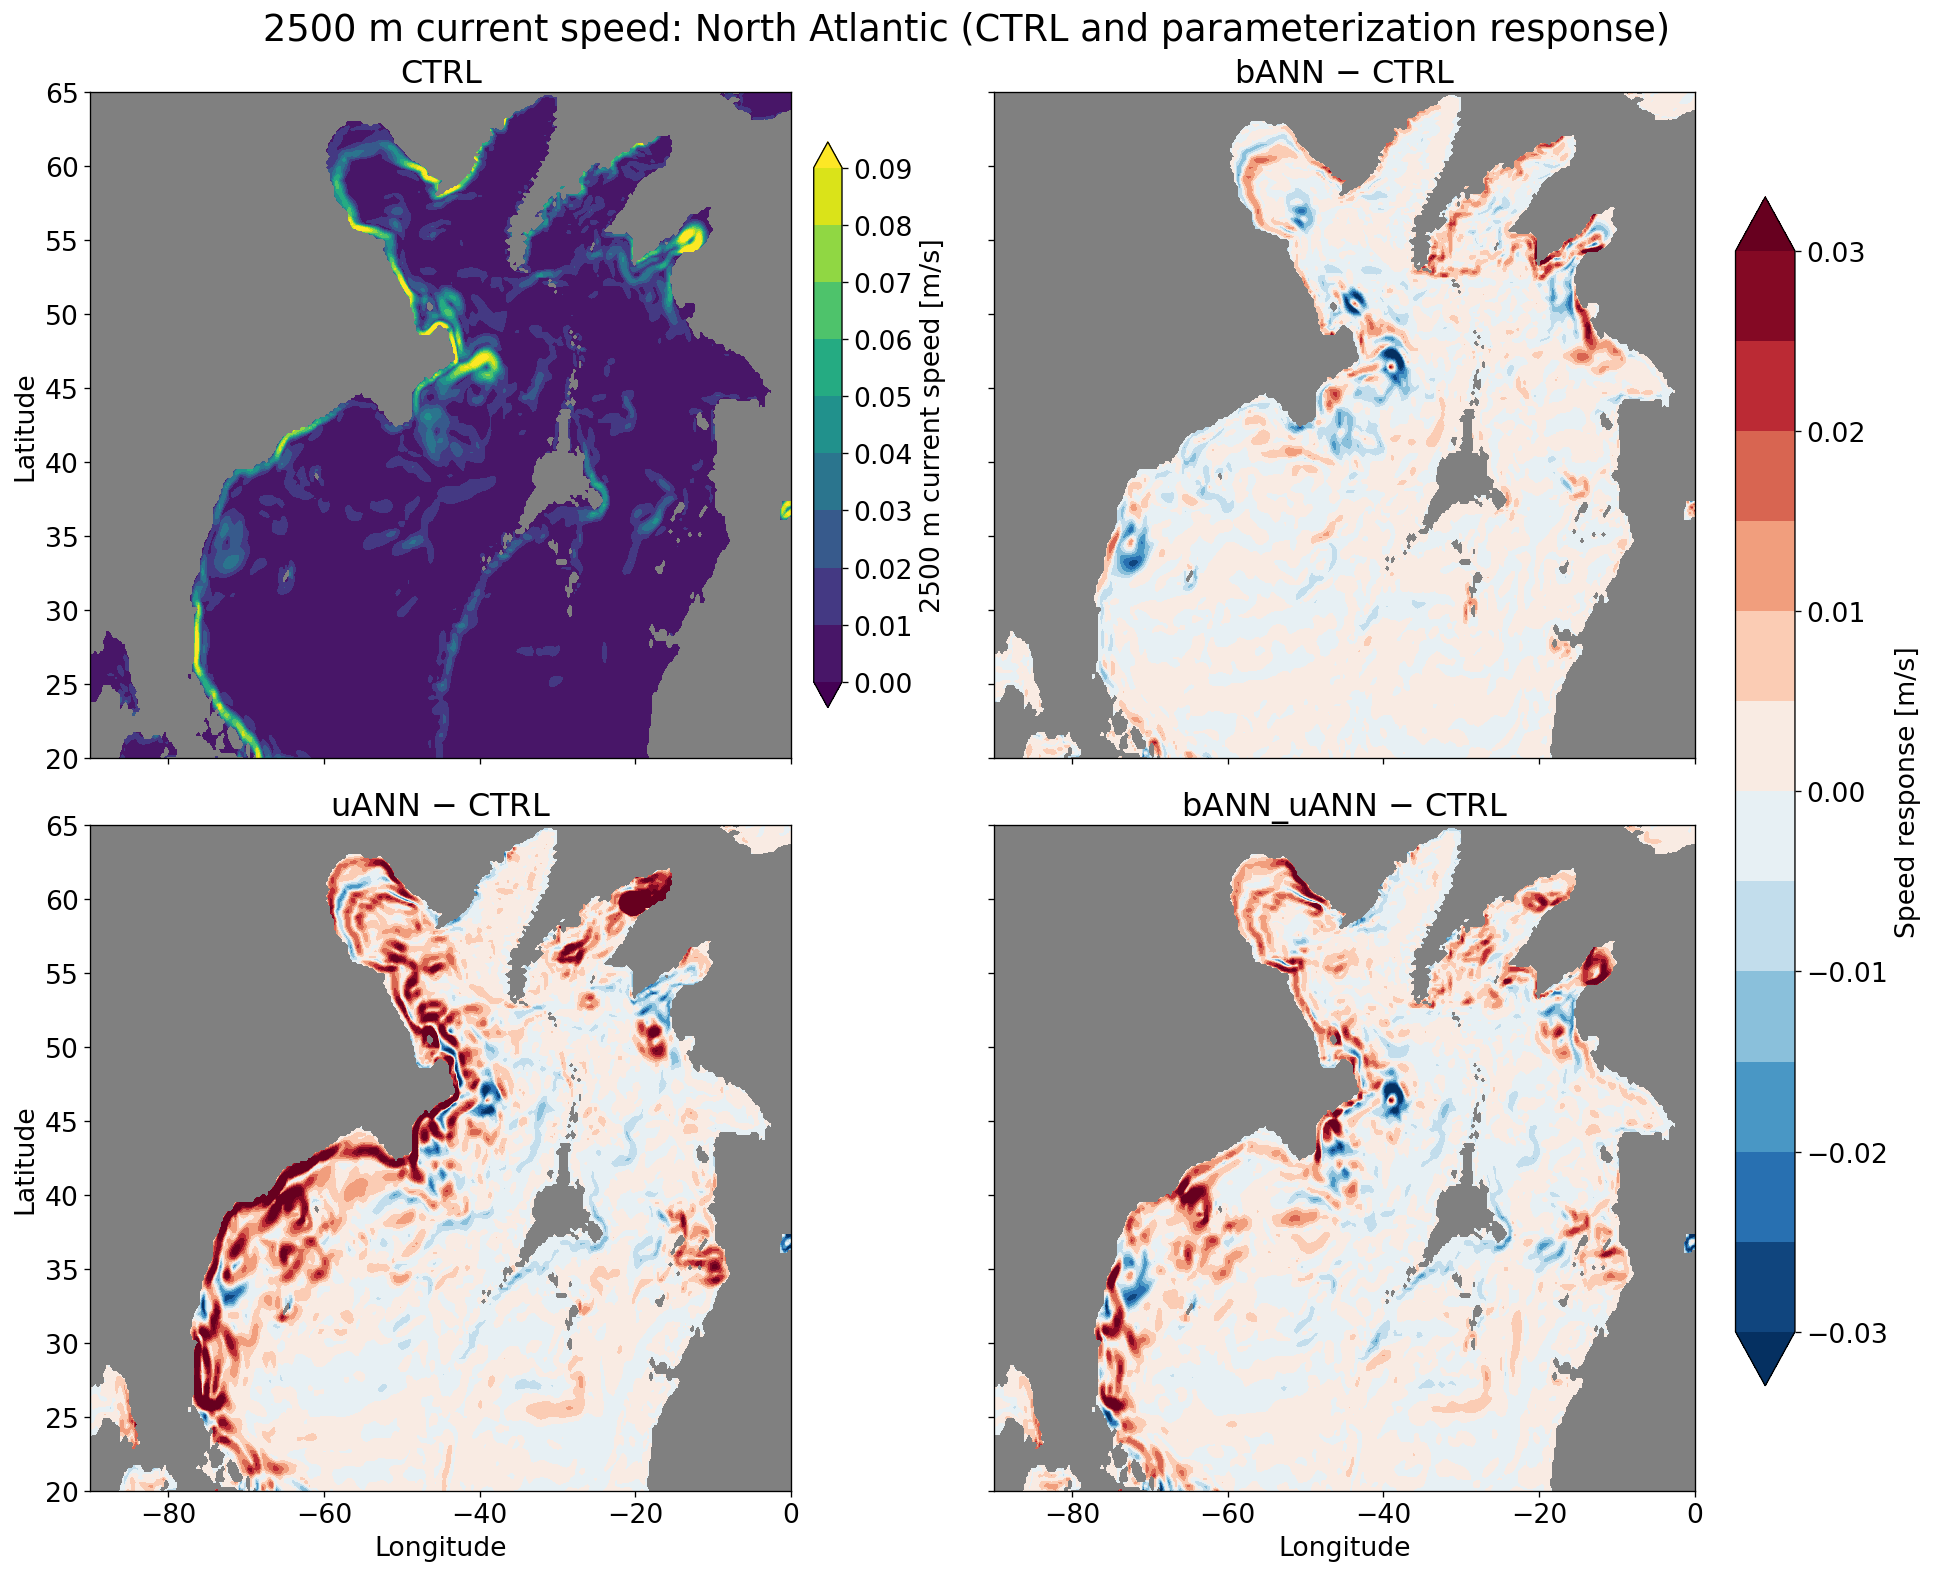

In [8]:
SPEED_2500_LEVELS = np.arange(0, 0.1, 0.01)          # m/s, CTRL absolute (dynamics.ipynb's own 2500m levels)
SPEED_2500_RESP_LEVELS = np.arange(-0.03, 0.035, 0.005)  # m/s, response (dynamics.ipynb's own levels)


def _speed_2500_xy(name):
    ds = xr.open_dataset(native_file(name, 'current_speed.nc'))
    grd = nexps[name].grd
    return grd.geolon.values, grd.geolat.values, ds['speed_2500m'].values


plot_native_response_2x2(_speed_2500_xy, SPEED_2500_LEVELS, 'viridis', '2500 m current speed [m/s]',
                         SPEED_2500_RESP_LEVELS, 'RdBu_r', 'Speed response [m/s]',
                         '2500 m current speed: North Atlantic (CTRL and parameterization response)',
                         xlim=NA_XLIM, ylim=NA_YLIM_SPEED)

# 5. Equatorial undercurrent section at 165E

Same diagnostic as `dynamics.ipynb`'s Section 9: a latitude-depth section
of zonal velocity `uo` at a single fixed longitude (165E, Tropical
Pacific), not averaged across a longitude band. `gfdl_native_velocity.py`
extracts the nearest native `xq` column (for `uo`) and `xh` column (for
`thetao`/`so`) to 165E, over the full available depth/latitude range; here
that's sliced to -8 to 8 latitude, 0-500 m depth, matching `dynamics.ipynb`
exactly.

- **Obs columns**: Johnson et al. equatorial climatology (`eq-uvts-johnson`)
  and the GLORYS12 quarter-degree reanalysis -- the same two references
  `dynamics.ipynb` uses for this section.
- **Every panel** overlays $\sigma_2$ (`gsw.sigma2`, kg m$^{-3}$) as
  labelled black isolines: Johnson `POTEMPM`/`SALINITYM` and GLORYS12
  `thetao`/`so` for the two obs panels, the model's own native-grid
  `thetao`/`so` (from `gfdl_native_velocity.py`, at the same section) for
  the 4 GFDL panels.
- One row of 6 panels (2 obs + 4 experiments), instead of
  `dynamics.ipynb`'s 2 rows x 4 columns -- GFDL has one regime, not two.

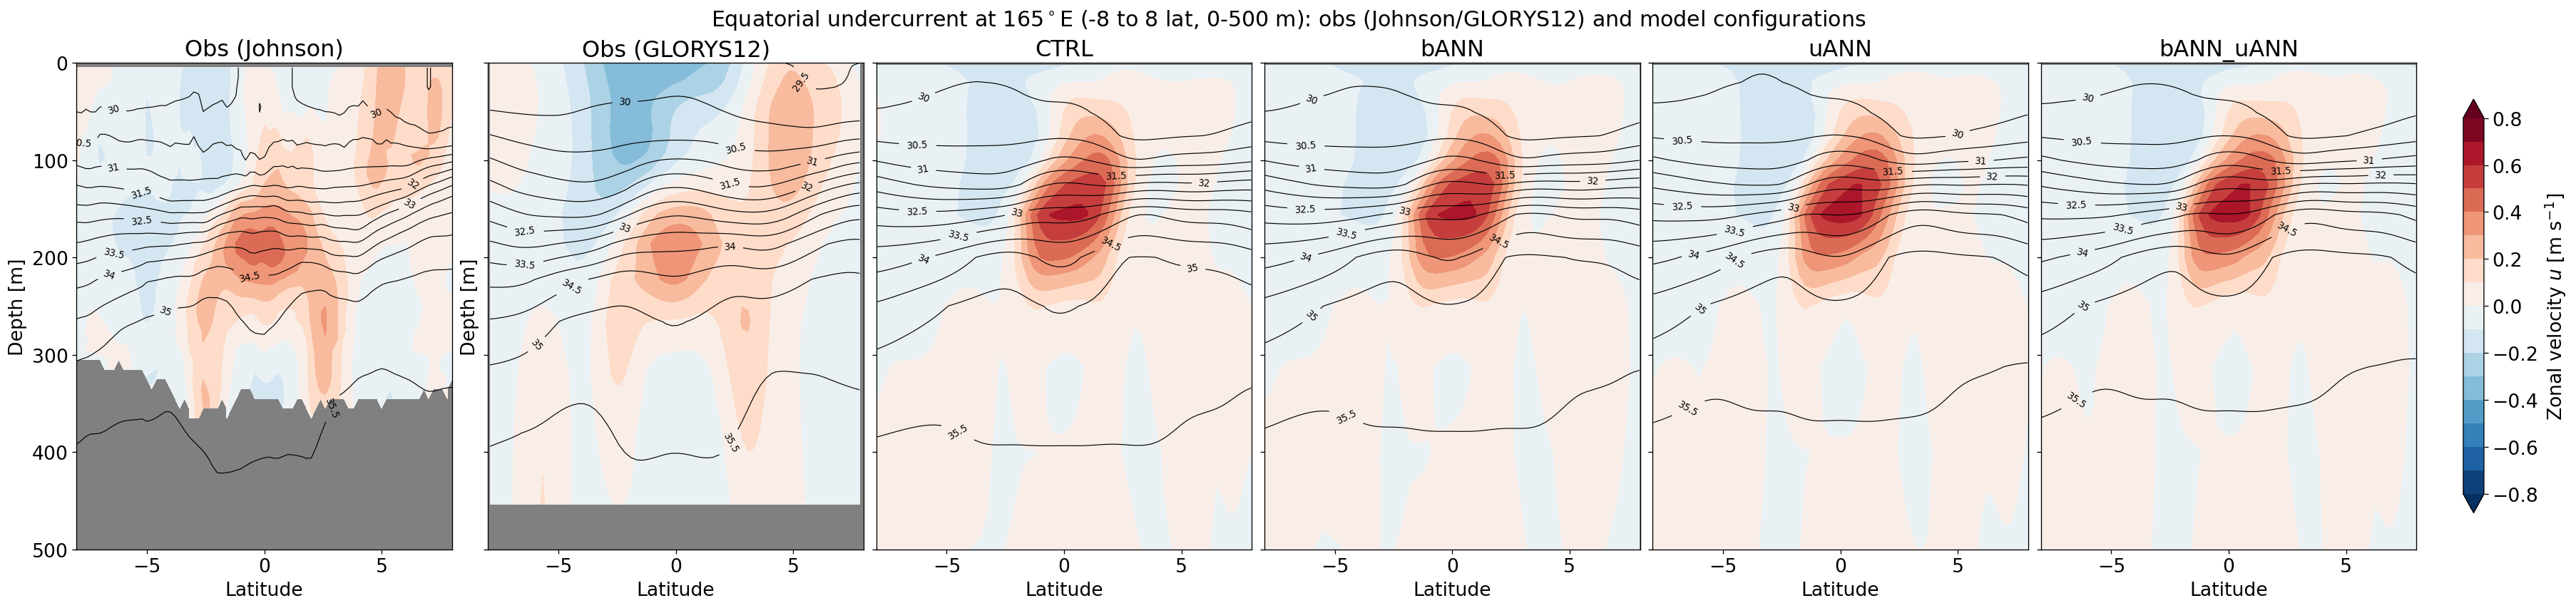

In [9]:
# Johnson et al. equatorial u/v/T climatology and the GLORYS12 quarter-degree
# reanalysis, same products/paths dynamics.ipynb's own EUC section uses.
cat = intake.open_catalog('/glade/u/home/gmarques/libs/oce-catalogs/reference-datasets.yml')
johnson = cat['eq-uvts-johnson'].to_dask()
GLORYS_QUARTER = ('/glade/work/pavelp/GLORYS12/coarse_quarter_degree/'
                  'mercatorglorys12v1_gl12_mean_1993_2016_quarter.nc')
glorys_q = xr.open_dataset(GLORYS_QUARTER)

EUC_LON = 165.0   # deg E, matches gfdl_native_velocity.py's own EUC_LON
EUC_LAT = slice(-8, 8)
EUC_DEPTH = 500   # m

u_obs_sec = (johnson['UM'].sel(XLON=EUC_LON, method='nearest')
             .sel(ZDEP1_50=slice(0, EUC_DEPTH), YLAT11_101=EUC_LAT))
sigma2_obs_sec = gsw.sigma2(
    johnson['SALINITYM'].sel(XLON=EUC_LON, method='nearest')
        .sel(ZDEP1_50=slice(0, EUC_DEPTH), YLAT11_101=EUC_LAT),
    johnson['POTEMPM'].sel(XLON=EUC_LON, method='nearest')
        .sel(ZDEP1_50=slice(0, EUC_DEPTH), YLAT11_101=EUC_LAT))

# GLORYS12's longitude is -180..180; EUC_LON (165) is already in that range,
# but wrap generically in case of a future longitude choice that isn't.
glorys_lon = ((EUC_LON + 180.0) % 360.0) - 180.0


def _glorys_sec(var):
    return (glorys_q[var].sel(longitude=glorys_lon, method='nearest')
            .sel(depth=slice(0, EUC_DEPTH)).sortby('latitude').sel(latitude=EUC_LAT))


u_gl_sec = _glorys_sec('uo')
sigma2_gl_sec = gsw.sigma2(_glorys_sec('so'), _glorys_sec('thetao'))


def _model_euc_uo(name):
    """Model zonal velocity at EUC_LON (native xq column): (lat, depth, field)."""
    ds = xr.open_dataset(native_file(name, 'euc_section.nc'))
    u = ds['uo'].sel(yh_u=EUC_LAT, z_l=slice(0, EUC_DEPTH))
    return u['yh_u'].values, u['z_l'].values, u.values


def _model_euc_sigma2(name):
    """Model sigma2 at EUC_LON (native xh column): (lat, depth, field)."""
    ds = xr.open_dataset(native_file(name, 'euc_section.nc'))
    so_ = ds['so'].sel(yh=EUC_LAT, z_l=slice(0, EUC_DEPTH))
    th_ = ds['thetao'].sel(yh=EUC_LAT, z_l=slice(0, EUC_DEPTH))
    s2 = gsw.sigma2(so_, th_)
    return s2['yh'].values, s2['z_l'].values, s2.values


EUC_UO_LEVELS = np.arange(-0.8, 0.9, 0.1)         # m/s, matches dynamics.ipynb's own UO_LEVELS
EUC_SIGMA2_LEVELS = np.arange(29.0, 36.01, 0.5)   # kg/m^3, matches dynamics.ipynb's own SIGMA2_EQ_LEVELS

obs_panels = [
    ('Obs (Johnson)', u_obs_sec['YLAT11_101'].values, u_obs_sec['ZDEP1_50'].values,
     u_obs_sec.values, sigma2_obs_sec.values),
    ('Obs (GLORYS12)', u_gl_sec['latitude'].values, u_gl_sec['depth'].values,
     u_gl_sec.values, sigma2_gl_sec.values),
]

fig, axes = plt.subplots(1, len(obs_panels) + len(nnames), figsize=(30, 7), dpi=120,
                         sharex=True, sharey=True, constrained_layout=True)
cf = None
for j, (title, lat_o, z_o, u_o, sigma2_o) in enumerate(obs_panels):
    ax = axes[j]
    ax.set_facecolor('gray')
    cf = ax.contourf(lat_o, z_o, u_o, levels=EUC_UO_LEVELS, cmap='RdBu_r', extend='both')
    cs = ax.contour(lat_o, z_o, sigma2_o, levels=EUC_SIGMA2_LEVELS, colors='k', linewidths=0.7)
    ax.clabel(cs, fmt='%g', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Depth [m]')
for i, name in enumerate(nnames):
    ax = axes[len(obs_panels) + i]
    ax.set_facecolor('gray')
    lat_u, z_u, u = _model_euc_uo(name)
    cf = ax.contourf(lat_u, z_u, u, levels=EUC_UO_LEVELS, cmap='RdBu_r', extend='both')
    lat_t, z_t, s2 = _model_euc_sigma2(name)
    cs = ax.contour(lat_t, z_t, s2, levels=EUC_SIGMA2_LEVELS, colors='k', linewidths=0.7)
    ax.clabel(cs, fmt='%g', fontsize=8)
    ax.set_title(NLABELS[name])
for ax in axes:
    ax.set_xlim(-8, 8)
    ax.set_ylim(EUC_DEPTH, 0)
    ax.set_xlabel('Latitude')
fig.colorbar(cf, ax=axes, label='Zonal velocity $u$ [m s$^{-1}$]', extend='both', shrink=0.85, pad=0.02)
fig.suptitle(f'Equatorial undercurrent at {EUC_LON:.0f}' r'$^\circ$E'
             ' (-8 to 8 lat, 0-500 m): obs (Johnson/GLORYS12) and model configurations',
             fontsize=18)
plt.show()

# 6. ACC/Drake Passage zonal-velocity section at 70W

Same diagnostic as `dynamics.ipynb`'s Section 10: a latitude-depth section
of zonal velocity `uo` at 70W, 70-55S, 0-4500 m, where the Antarctic
Circumpolar Current (ACC) flows eastward through Drake Passage. Uses the
same native `xq`/`xh` columns `gfdl_native_velocity.py` already picks for
the Drake Passage transport time series (Section 7).

- **Obs column**: GLORYS12 quarter-degree reanalysis only -- the Johnson
  climatology is equatorial-only and doesn't reach these latitudes (same
  as `dynamics.ipynb`'s own note for this section).
- **Every panel** overlays $\sigma_2$ isolines (GLORYS12 for the obs panel,
  the model's own native-grid `thetao`/`so` for the 4 GFDL panels), and
  every model panel is annotated with the RMSE of its zonal velocity
  against GLORYS12 (interpolated onto the GLORYS12 section grid).
- One row of 5 panels (1 obs + 4 experiments), instead of
  `dynamics.ipynb`'s 2 rows x 4 columns (its left column repeats GLORYS12
  in both rows since Johnson doesn't reach here either) -- GFDL has one
  regime, not two.

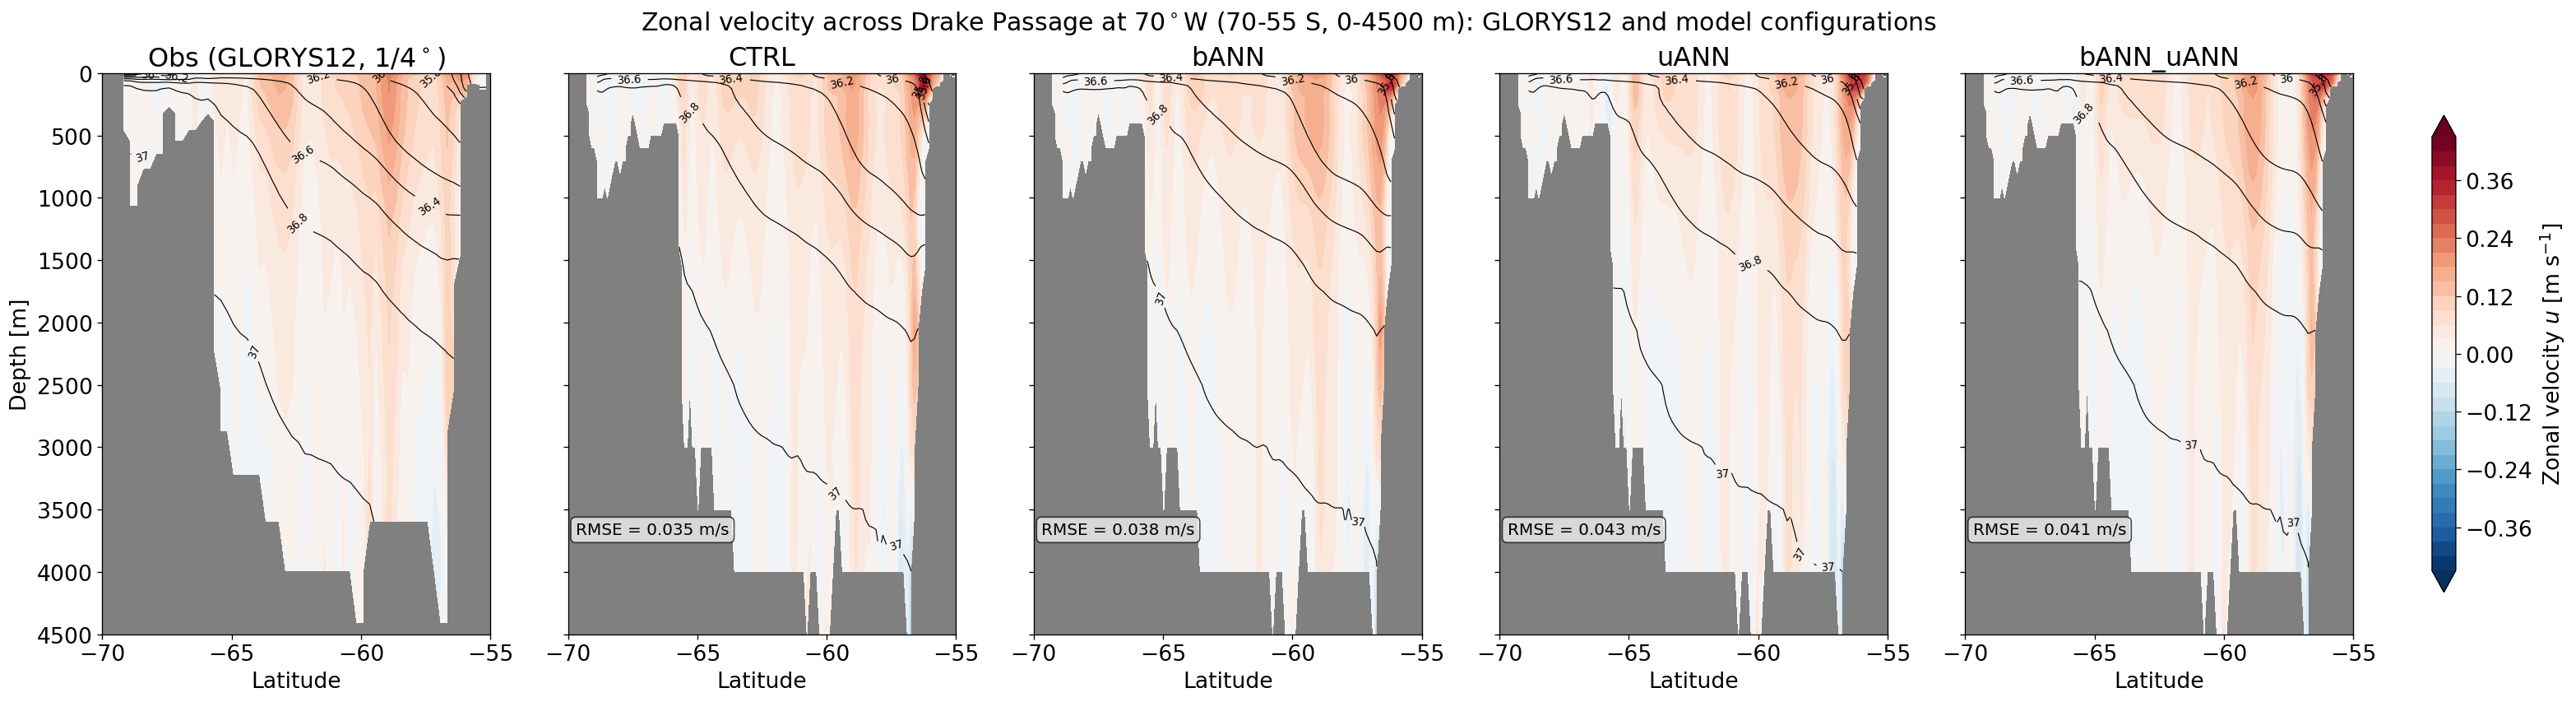

In [10]:
DRAKE_LON_E = 290.0   # 70W in 0-360 convention, matches dynamics.ipynb's own DRAKE_LON variable
DRAKE_LAT = slice(-70, -55)
DRAKE_DEPTH = 4500   # m

drake_lon_pm = ((DRAKE_LON_E + 180.0) % 360.0) - 180.0   # 290 -> -70


def _glorys_drake(var):
    return (glorys_q[var].sel(longitude=drake_lon_pm, method='nearest')
            .sel(depth=slice(0, DRAKE_DEPTH)).sortby('latitude').sel(latitude=DRAKE_LAT))


u_gl_drake = _glorys_drake('uo')
sigma2_gl_drake = gsw.sigma2(_glorys_drake('so'), _glorys_drake('thetao'))


def _model_drake_uo(name):
    """Model zonal velocity at 70W (native xq column): (lat, depth, field)."""
    ds = xr.open_dataset(native_file(name, 'drake_section.nc'))
    u = ds['uo'].sel(yh_u=DRAKE_LAT, z_l=slice(0, DRAKE_DEPTH))
    return u['yh_u'].values, u['z_l'].values, u.values


def _model_drake_sigma2(name):
    """Model sigma2 at 70W (native xh column): (lat, depth, field)."""
    ds = xr.open_dataset(native_file(name, 'drake_section.nc'))
    so_ = ds['so'].sel(yh=DRAKE_LAT, z_l=slice(0, DRAKE_DEPTH))
    th_ = ds['thetao'].sel(yh=DRAKE_LAT, z_l=slice(0, DRAKE_DEPTH))
    s2 = gsw.sigma2(so_, th_)
    return s2['yh'].values, s2['z_l'].values, s2.values


def _rmse_drake(lat_u, z_u, u):
    """RMSE of a model section vs GLORYS12, on the GLORYS12 section grid [m/s]."""
    u_da = xr.DataArray(u, dims=['z_l', 'yh_u'], coords={'z_l': z_u, 'yh_u': lat_u})
    u_i = u_da.interp(z_l=u_gl_drake['depth'], yh_u=u_gl_drake['latitude'])
    diff = u_i.values - u_gl_drake.values
    return float(np.sqrt(np.nanmean(diff ** 2)))


DRAKE_UO_LEVELS = np.arange(-0.45, 0.46, 0.03)         # m/s, dynamics.ipynb uses +-0.3 (its own ACC peak);
                                                       # checked directly: GFDL's ACC core peaks ~0.43 m/s,
                                                       # so widened (same 0.03 step) to avoid heavy saturation
DRAKE_SIGMA2_LEVELS = np.arange(30.0, 37.61, 0.2)      # kg/m^3, matches dynamics.ipynb's own SIGMA2_DRAKE_LEVELS

fig, axes = plt.subplots(1, 1 + len(nnames), figsize=(26, 7), dpi=120,
                         sharex=True, sharey=True, constrained_layout=True)
cf = None
ax = axes[0]
ax.set_facecolor('gray')
cf = ax.contourf(u_gl_drake['latitude'].values, u_gl_drake['depth'].values, u_gl_drake.values,
                 levels=DRAKE_UO_LEVELS, cmap='RdBu_r', extend='both')
cs = ax.contour(u_gl_drake['latitude'].values, u_gl_drake['depth'].values, sigma2_gl_drake.values,
                levels=DRAKE_SIGMA2_LEVELS, colors='k', linewidths=0.7)
ax.clabel(cs, fmt='%g', fontsize=8)
ax.set_title(r'Obs (GLORYS12, 1/4$^\circ$)')
ax.set_ylabel('Depth [m]')
for i, name in enumerate(nnames):
    ax = axes[1 + i]
    ax.set_facecolor('gray')
    lat_u, z_u, u = _model_drake_uo(name)
    cf = ax.contourf(lat_u, z_u, u, levels=DRAKE_UO_LEVELS, cmap='RdBu_r', extend='both')
    lat_t, z_t, s2 = _model_drake_sigma2(name)
    cs = ax.contour(lat_t, z_t, s2, levels=DRAKE_SIGMA2_LEVELS, colors='k', linewidths=0.7)
    ax.clabel(cs, fmt='%g', fontsize=8)
    rmse = _rmse_drake(lat_u, z_u, u)
    ax.text(0.02, 0.2, f'RMSE = {rmse:.3f} m/s', transform=ax.transAxes,
           va='top', ha='left', fontsize=12,
           bbox=dict(boxstyle='round', fc='white', alpha=0.7))
    ax.set_title(NLABELS[name])
for ax in axes:
    ax.set_xlim(-70, -55)
    ax.set_ylim(DRAKE_DEPTH, 0)
    ax.set_xlabel('Latitude')
fig.colorbar(cf, ax=axes, label='Zonal velocity $u$ [m s$^{-1}$]', extend='both', shrink=0.85, pad=0.02)
fig.suptitle('Zonal velocity across Drake Passage at 70' r'$^\circ$W'
             ' (70-55 S, 0-4500 m): GLORYS12 and model configurations',
             fontsize=18)
plt.show()

# 7. ACC transport in Drake Passage

Annual volume transport through Drake Passage (the nearest native `xq`
column to 70W, integrated over depth and over its Southern-Ocean latitude
range, 71S-55S), from real `umo` -- the same native `xq` column Section 6's
zonal-velocity section uses. Full available record per experiment (not
just 1988-2012), matching the AMOC/heat-transport time-series convention
already established in `gfdl_moc.ipynb`.

**Shown as a single combined-line plot (all 4 experiments overlaid, CTRL in
black), not a 2x2 grid.** This is an intentional departure from Sections
3-4's layout: Drake Passage transport is a scalar per year, not a spatial
field, so a 2x2 grid of near-identical flat lines would waste the layout
without adding information -- `gfdl_moc.ipynb`'s own AMOC and heat-transport
time-series sections use one combined-line panel for exactly this kind of
scalar time series, and this follows the same convention.

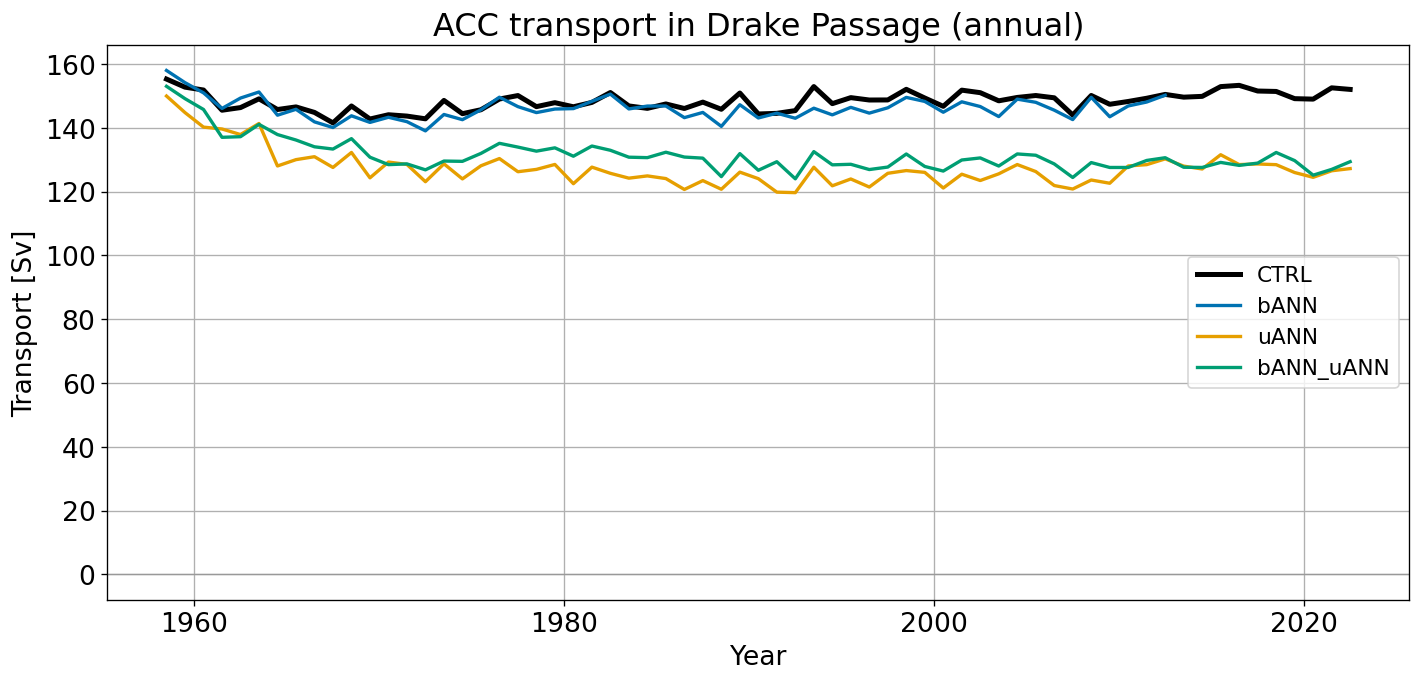

In [11]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
ax.axhline(0, color='0.6', lw=0.8)
for name in nnames:
    ds = xr.open_dataset(native_file(name, 'drake_transport.nc'))
    ts = ds['drake_transport']
    is_ctrl = name == NCTRL
    ts.plot(ax=ax, x='time', label=NLABELS[name], lw=3 if is_ctrl else 2, color=NCOLORS[name])
ax.set_title('ACC transport in Drake Passage (annual)')
ax.set_xlabel('Year')
ax.set_ylabel('Transport [Sv]')
ax.grid(True)
ax.legend(loc='best', fontsize=13)
plt.show()